In [2]:
import pandas as pd
import joblib

import matplotlib.pyplot as plt

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

In [3]:
X_test = pd.read_csv("../Data/Processed/X_test.csv")
y_test = pd.read_csv("../Data/Processed/y_test.csv").squeeze()

In [5]:
import os

# List files in the model directory to find the correct path
print(os.listdir("../model/"))

['best_regression_model.pkl']


In [6]:
model = joblib.load("../model/best_regression_model.pkl")

In [7]:
y_pred = model.predict(X_test)

In [11]:
r2 = r2_score(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("R² Score :", round(r2,4))
print("RMSE     :", round(rmse,4))
print("MAE      :", round(mae,4))

R² Score : 0.5157
RMSE     : 0.6947
MAE      : 0.5074


In [12]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,1.560142,1.162186
1,-0.046810,0.370179
2,-0.046810,-0.787863
3,-0.046810,0.128592
4,-1.653762,-0.882955
5,-0.046810,-0.375493
6,-0.046810,-0.903216
7,-1.653762,-1.004021
8,3.167094,1.471045
9,-0.046810,-0.183589


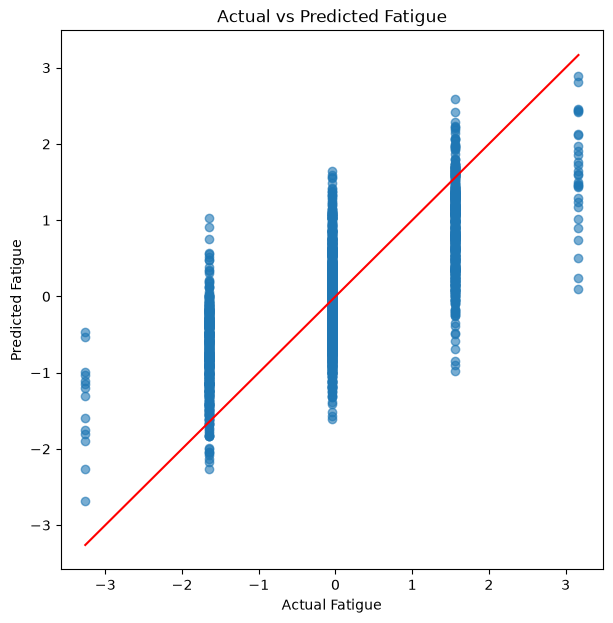

In [13]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Fatigue")
plt.ylabel("Predicted Fatigue")
plt.title("Actual vs Predicted Fatigue")

plt.show()

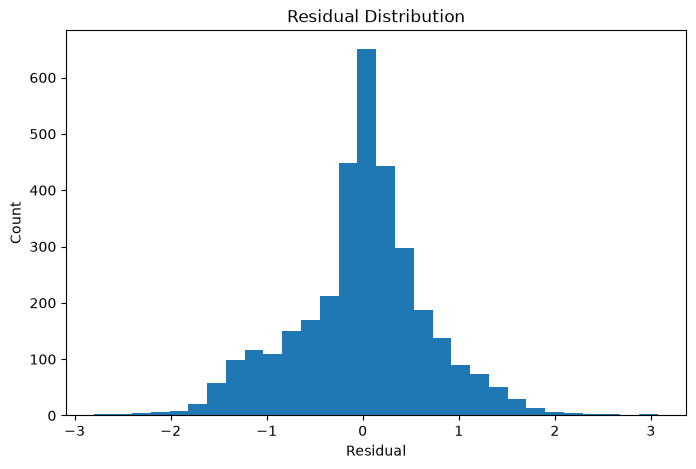

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")

plt.show()

In [15]:
importance = pd.DataFrame({

    "Feature": X_test.columns,
    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
12,soreness,0.392045
9,readiness,0.298671
11,sleep_quality,0.088699
8,mood,0.066529
13,stress,0.049082
10,sleep_duration,0.031338
3,ctl42,0.013996
7,weekly_load,0.012710
6,strain,0.011064
2,ctl28,0.010840


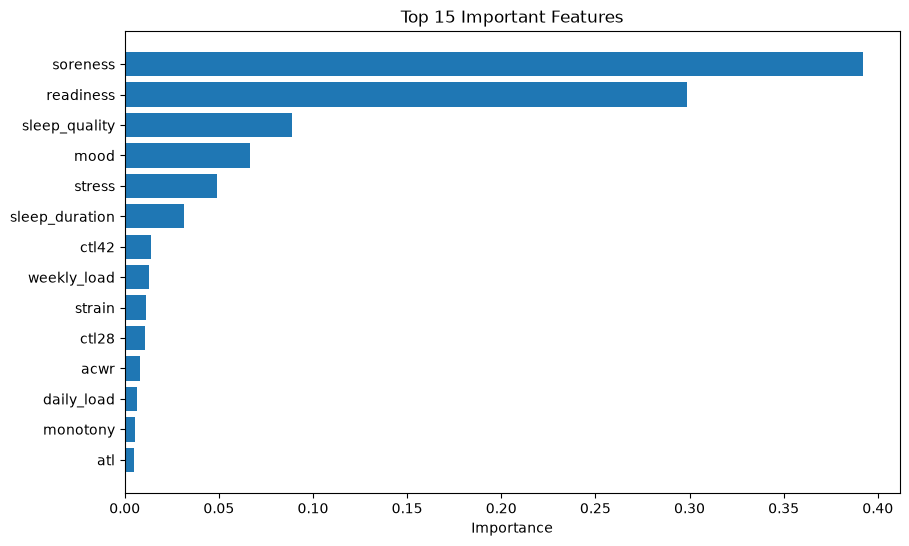

In [16]:
top = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.show()

In [17]:
results.to_csv(
    "../Data/Processed/fatigue_predictions.csv",
    index=False
)

## Model Evaluation Summary

Target Variable:
- Fatigue

Best Model:
- Gradient Boosting Regressor

Performance:

- Test R²  : 0.516
- RMSE     : 0.695
- MAE      : (calculated)

Conclusion:

The Gradient Boosting Regressor achieved the highest predictive performance among all evaluated models. The model explains approximately 52% of the variance in player fatigue using training load, wellness, and other engineered features. Feature importance analysis identifies the variables that contribute most to fatigue prediction and can support data-driven athlete monitoring.